# FakeNewsNet Exploratory Data Analysis

This notebook performs EDA on the processed fake news dataset and saves figures to `results/figures/eda_*.png`.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

sns.set_theme(style="whitegrid")

cwd = Path.cwd()
if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root containing data/ directory.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: "Real", 1: "Fake"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Project root: /home/soham/cs592-eai/fake-news/fake_news_xai
Processed dir: /home/soham/cs592-eai/fake-news/fake_news_xai/data/processed
Figures dir: /home/soham/cs592-eai/fake-news/fake_news_xai/results/figures


In [2]:
processed_csv = PROCESSED_DIR / "processed.csv"
train_csv = PROCESSED_DIR / "train.csv"
test_csv = PROCESSED_DIR / "test.csv"

if processed_csv.exists():
    df = pd.read_csv(processed_csv)
elif train_csv.exists() and test_csv.exists():
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    df = pd.concat([train_df, test_df], ignore_index=True)
else:
    raise FileNotFoundError("Expected processed.csv or both train.csv and test.csv in data/processed")

required_cols = {"title", "text", "full_text", "label", "text_length", "has_author"}
missing = required_cols.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df["label_name"] = df["label"].map(LABEL_MAP)
df["full_text"] = df["full_text"].fillna("").astype(str)
df["text_length"] = pd.to_numeric(df["text_length"], errors="coerce")
df["has_author"] = pd.to_numeric(df["has_author"], errors="coerce").fillna(0).astype(int)

display(df.head(3))
print(f"Dataset shape: {df.shape}")
print(df["label_name"].value_counts())

,id,title,text,full_text,label,source,text_length,has_author,label_name
0,true_13447,france invites u.s. to dec. 13 summit on boost...,accra (reuters) - french president emmanuel ma...,france invites u.s. to dec. 13 summit on boost...,0,worldnews,415,0,Real
1,true_7067,trump keeps politics on his thanksgiving menu,"west palm beach, fla./washington (reuters) - u...",trump keeps politics on his thanksgiving menu ...,0,politicsNews,796,0,Real
2,true_13988,ireland's fianna fail party says will be elect...,dublin (reuters) - ireland s second-largest pa...,ireland's fianna fail party says will be elect...,0,worldnews,89,0,Real


Dataset shape: (44898, 9)
label_name
Fake    23481
Real    21417
Name: count, dtype: int64


## 1) Class Balance

Counts of real vs fake articles in the processed dataset.

/tmp/ipykernel_594083/609983406.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette=["#2E86AB", "#E07A5F"])


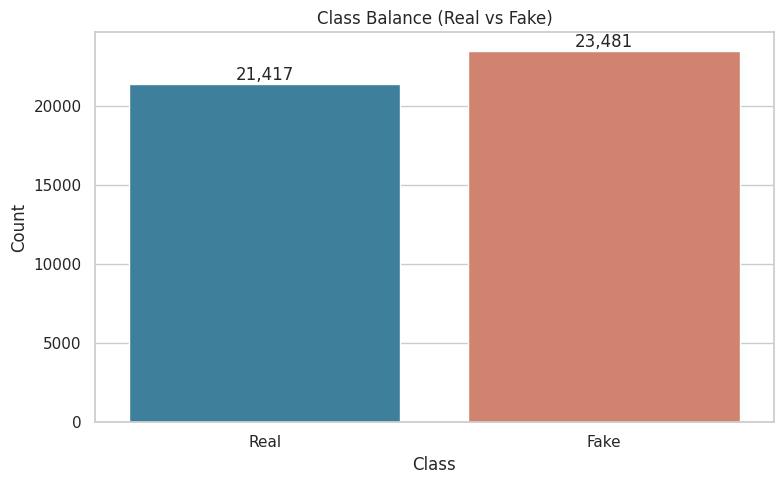

In [3]:
label_counts = df["label_name"].value_counts().reindex(["Real", "Fake"])

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette=["#2E86AB", "#E07A5F"])
ax.set_title("Class Balance (Real vs Fake)")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()

## 2) Text Length Distribution by Class

Distribution of article lengths using word counts.

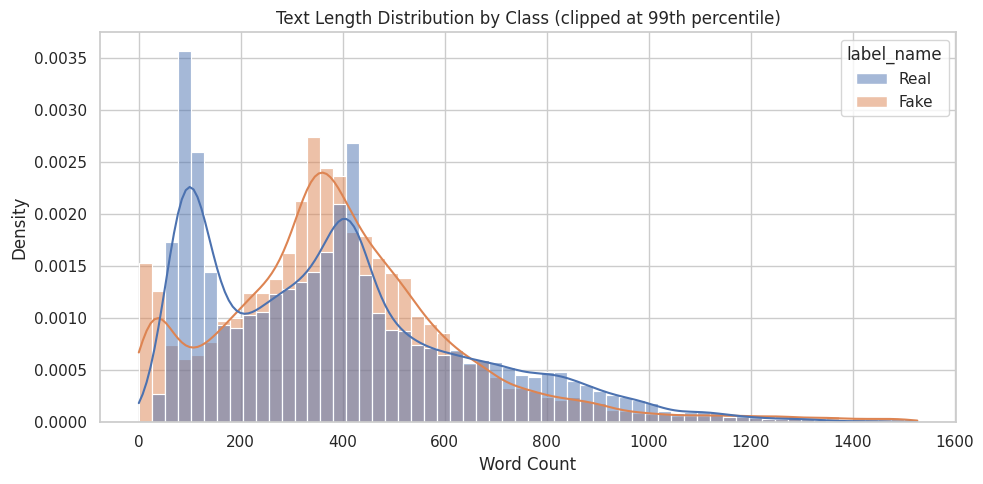

In [4]:
plot_df = df.copy()
clip_upper = plot_df["text_length"].quantile(0.99)
plot_df = plot_df[plot_df["text_length"] <= clip_upper]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x="text_length",
    hue="label_name",
    bins=60,
    kde=True,
    stat="density",
    common_norm=False,
)
plt.title("Text Length Distribution by Class (clipped at 99th percentile)")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_text_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3) Top 30 TF-IDF Words (Fake vs Real)

Top weighted unigrams per class using TF-IDF means.

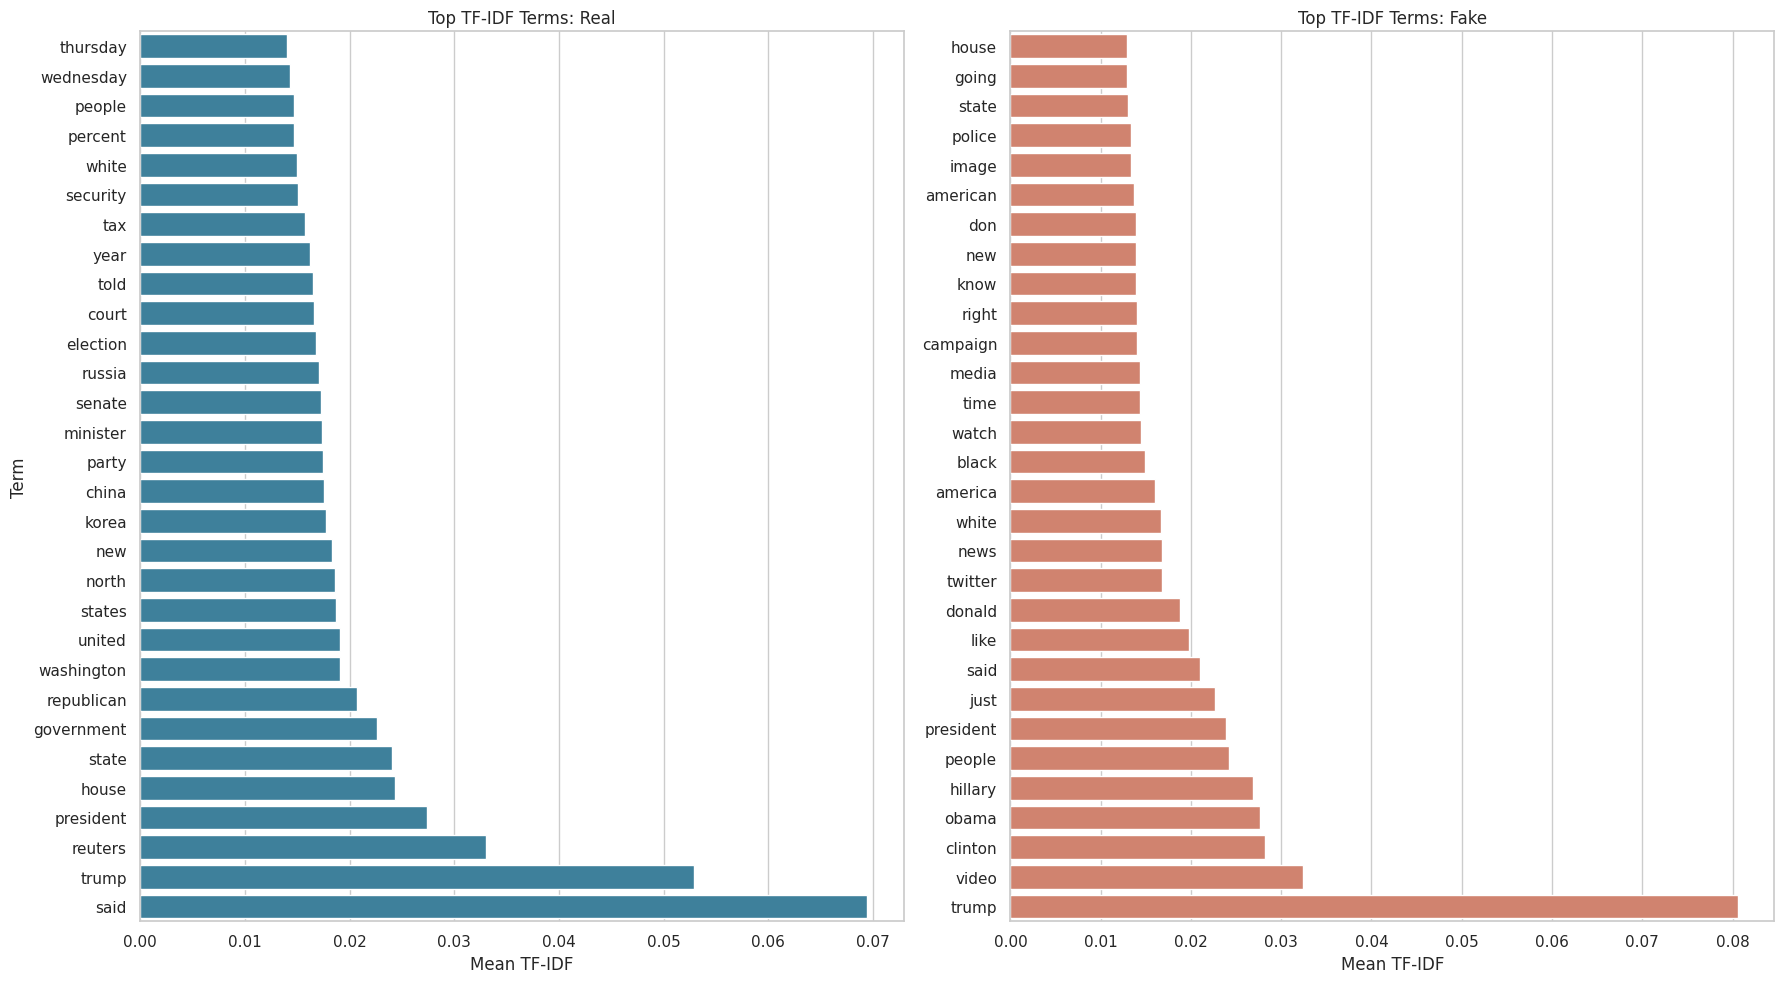

In [5]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(df["full_text"])
terms = np.array(vectorizer.get_feature_names_out())

top_words = {}
for label in [0, 1]:
    class_mask = df["label"].values == label
    class_mean = np.asarray(X[class_mask].mean(axis=0)).ravel()
    idx = np.argsort(class_mean)[-30:][::-1]
    top_words[label] = pd.DataFrame({
        "term": terms[idx],
        "score": class_mean[idx]
    })

fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=False)

sns.barplot(data=top_words[0].sort_values("score"), x="score", y="term", ax=axes[0], color="#2E86AB")
axes[0].set_title("Top TF-IDF Terms: Real")
axes[0].set_xlabel("Mean TF-IDF")
axes[0].set_ylabel("Term")

sns.barplot(data=top_words[1].sort_values("score"), x="score", y="term", ax=axes[1], color="#E07A5F")
axes[1].set_title("Top TF-IDF Terms: Fake")
axes[1].set_xlabel("Mean TF-IDF")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_top_words_tfidf.png", dpi=300, bbox_inches="tight")
plt.show()

## 4) Sentiment Polarity by Class (TextBlob)

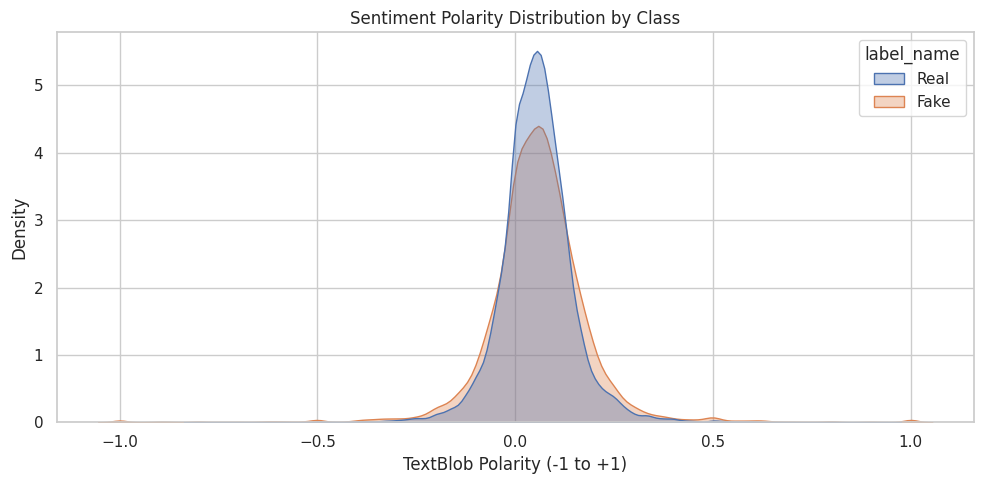

In [6]:
df["sentiment_polarity"] = df["full_text"].apply(lambda t: TextBlob(t).sentiment.polarity)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="sentiment_polarity", hue="label_name", common_norm=False, fill=True, alpha=0.35)
plt.title("Sentiment Polarity Distribution by Class")
plt.xlabel("TextBlob Polarity (-1 to +1)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5) Readability by Class (Flesch-Kincaid Grade)

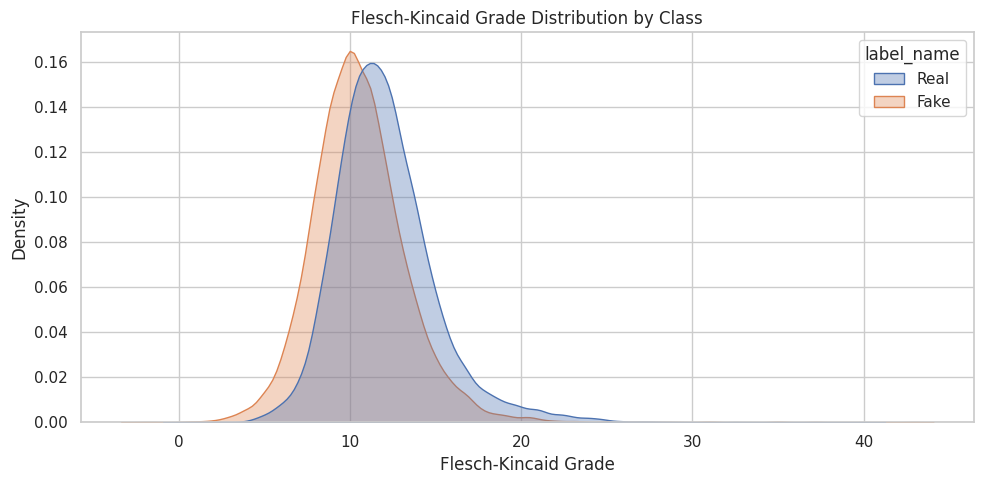

In [7]:
VOWEL_RE = re.compile(r"[aeiouy]+", re.IGNORECASE)

def count_syllables(word: str) -> int:
    word = re.sub(r"[^a-z]", "", word.lower())
    if not word:
        return 0
    syllables = len(VOWEL_RE.findall(word))
    if word.endswith("e") and syllables > 1:
        syllables -= 1
    return max(1, syllables)

def flesch_kincaid_grade(text: str) -> float:
    text = str(text)
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    words = re.findall(r"\b\w+\b", text)
    num_sentences = len(sentences)
    num_words = len(words)
    if num_sentences == 0 or num_words == 0:
        return np.nan
    num_syllables = sum(count_syllables(w) for w in words)
    return 0.39 * (num_words / num_sentences) + 11.8 * (num_syllables / num_words) - 15.59

df["readability_fk"] = df["full_text"].apply(flesch_kincaid_grade)

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df.dropna(subset=["readability_fk"]), x="readability_fk", hue="label_name", common_norm=False, fill=True, alpha=0.35)
plt.title("Flesch-Kincaid Grade Distribution by Class")
plt.xlabel("Flesch-Kincaid Grade")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_readability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6) Has-Author Rate by Class

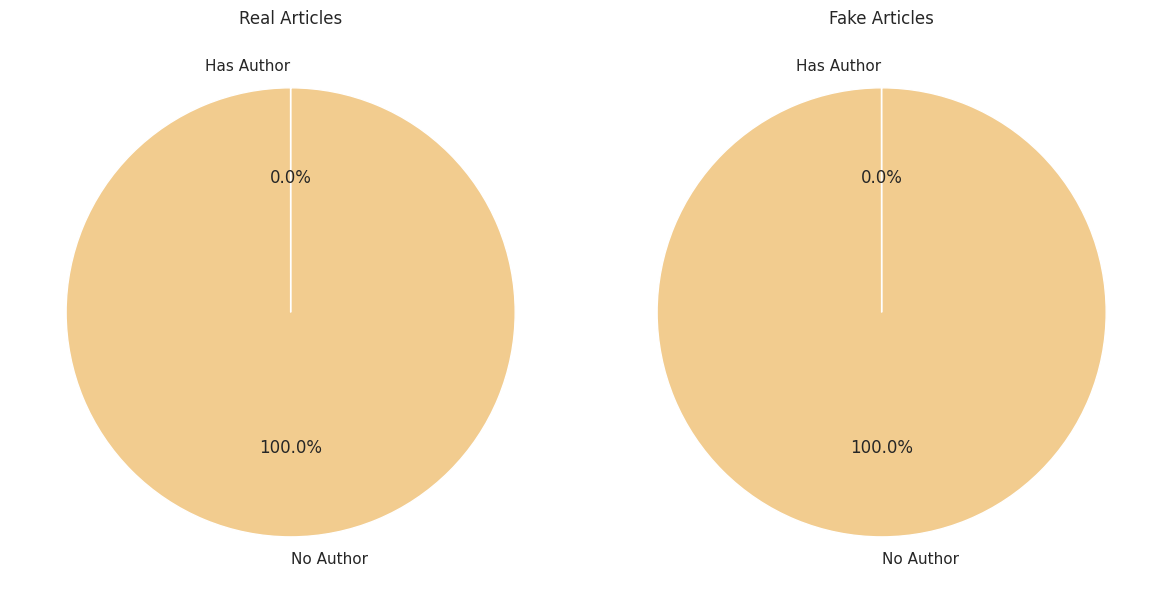

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, label in enumerate([0, 1]):
    class_name = LABEL_MAP[label]
    counts = df.loc[df["label"] == label, "has_author"].value_counts().reindex([1, 0], fill_value=0)
    axes[i].pie(
        counts.values,
        labels=["Has Author", "No Author"],
        autopct="%1.1f%%",
        colors=["#81B29A", "#F2CC8F"],
        startangle=90
    )
    axes[i].set_title(f"{class_name} Articles")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_has_author_pie.png", dpi=300, bbox_inches="tight")
plt.show()

## 7) Summary Table of Descriptive Statistics

,n_articles,avg_text_length,median_text_length,avg_sentiment,avg_fk_grade,has_author_rate
label_name,,,,,,
Fake,23481,437.690,378.0,0.057,10.526,0.0
Real,21417,395.589,369.0,0.054,12.009,0.0


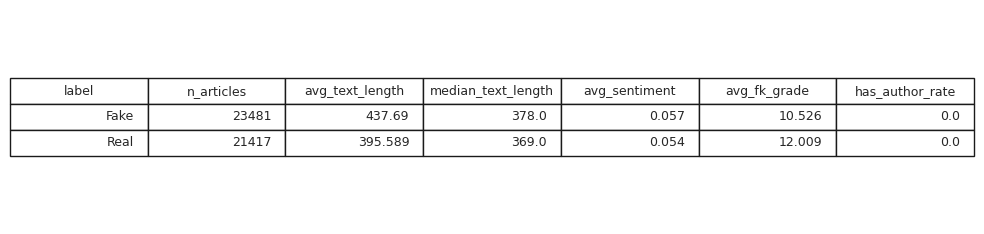

In [9]:
summary_table = pd.DataFrame({
    "n_articles": df.groupby("label_name").size(),
    "avg_text_length": df.groupby("label_name")["text_length"].mean(),
    "median_text_length": df.groupby("label_name")["text_length"].median(),
    "avg_sentiment": df.groupby("label_name")["sentiment_polarity"].mean(),
    "avg_fk_grade": df.groupby("label_name")["readability_fk"].mean(),
    "has_author_rate": df.groupby("label_name")["has_author"].mean()
}).round(3)

display(summary_table)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")
table = ax.table(
    cellText=summary_table.reset_index().values,
    colLabels=["label"] + list(summary_table.columns),
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Findings

In [10]:
fake_count = int((df["label"] == 1).sum())
real_count = int((df["label"] == 0).sum())
total_count = len(df)

avg_len_fake = df.loc[df["label"] == 1, "text_length"].mean()
avg_len_real = df.loc[df["label"] == 0, "text_length"].mean()

avg_sent_fake = df.loc[df["label"] == 1, "sentiment_polarity"].mean()
avg_sent_real = df.loc[df["label"] == 0, "sentiment_polarity"].mean()

avg_fk_fake = df.loc[df["label"] == 1, "readability_fk"].mean()
avg_fk_real = df.loc[df["label"] == 0, "readability_fk"].mean()

author_rate_fake = df.loc[df["label"] == 1, "has_author"].mean()
author_rate_real = df.loc[df["label"] == 0, "has_author"].mean()

findings_md = f"""
### EDA Findings
- Dataset size: **{total_count:,}** articles.
- Class balance: **Fake = {fake_count:,}** and **Real = {real_count:,}**.
- Average text length: **Fake = {avg_len_fake:.1f}** words, **Real = {avg_len_real:.1f}** words.
- Mean sentiment polarity: **Fake = {avg_sent_fake:.3f}**, **Real = {avg_sent_real:.3f}**.
- Mean Flesch-Kincaid grade: **Fake = {avg_fk_fake:.2f}**, **Real = {avg_fk_real:.2f}**.
- Has-author rate: **Fake = {author_rate_fake:.1%}**, **Real = {author_rate_real:.1%}**.

These findings can guide model design by highlighting differences in style, readability, and metadata cues between classes.
"""
display(Markdown(findings_md))


### EDA Findings
- Dataset size: **44,898** articles.
- Class balance: **Fake = 23,481** and **Real = 21,417**.
- Average text length: **Fake = 437.7** words, **Real = 395.6** words.
- Mean sentiment polarity: **Fake = 0.057**, **Real = 0.054**.
- Mean Flesch-Kincaid grade: **Fake = 10.53**, **Real = 12.01**.
- Has-author rate: **Fake = 0.0%**, **Real = 0.0%**.

These findings can guide model design by highlighting differences in style, readability, and metadata cues between classes.


## Final Key Findings
- Fake articles are somewhat longer and slightly less readable on average, while sentiment polarity is very similar across classes.